Customer Churn Prediction:

Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\VICTUS\OneDrive\Tài liệu\Telco Customer Churn Analysis\Data\Telco-Customer-Churn.csv")

In [3]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CustomerID      100000 non-null  int64  
 1   Age             100000 non-null  int64  
 2   Gender          100000 non-null  object 
 3   Tenure          100000 non-null  int64  
 4   MonthlyCharges  100000 non-null  float64
 5   Contract        100000 non-null  object 
 6   PaymentMethod   100000 non-null  object 
 7   TotalCharges    100000 non-null  float64
 8   Churn           100000 non-null  object 
dtypes: float64(2), int64(3), object(4)
memory usage: 6.9+ MB


In [45]:
df.describe()

,Age,Tenure,MonthlyCharges,TotalCharges
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,49.027240,36.527090,79.974933,2926.140256
std,18.177862,20.789552,40.491961,2388.163672
min,18.000000,1.000000,10.000000,-118.430000
25%,33.000000,18.000000,44.720000,963.667500
50%,49.000000,37.000000,80.000000,2268.060000
75%,65.000000,54.000000,115.050000,4394.327500
max,80.000000,72.000000,150.000000,10831.460000


In [ ]:
df.isnull()

Data Preprocessing

In [7]:
# customerid not needed:
df.drop("CustomerID", axis = 1, inplace = True)

In [8]:
# Converting datatype of TotalCharges:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors = "coerce")

In [9]:
# Filling the missing values if present:
df.fillna(df.mean(numeric_only = True), inplace = True)

EDA

In [18]:
df.groupby("Gender")["Churn"].value_counts().unstack()

Churn,No,Yes
Gender,,
Female,32405,15851
Male,31833,15954
Other,2618,1339


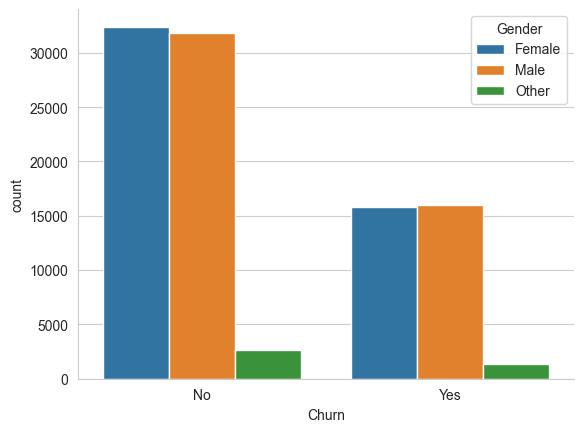

In [14]:
sns.countplot(data = df, x = "Churn", hue = "Gender")
sns.set_style("whitegrid")
sns.despine()
plt.show()

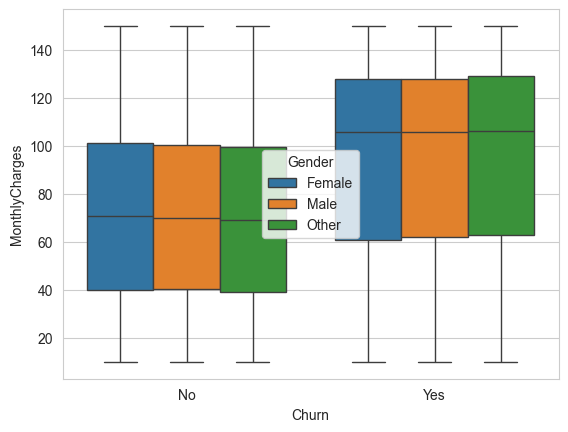

In [34]:
sns.boxplot(data = df, x = "Churn", y = "MonthlyCharges", hue = "Gender")
plt.show()

Encoding

In [35]:
df = pd.get_dummies(df, drop_first = True)

Train-Test Split

In [38]:
X = df.drop("Churn_Yes",axis = 1)
y = df["Churn_Yes"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

Model Training

In [39]:
model = RandomForestClassifier(n_estimators = 100, random_state = 42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Evalution

In [40]:
print(classification_report(y_test, y_pred))
print("ROC-AUC : ", roc_auc_score(y_test, y_pred))


              precision    recall  f1-score   support

       False       0.77      0.85      0.81     13294
        True       0.62      0.50      0.56      6706

    accuracy                           0.73     20000
   macro avg       0.70      0.67      0.68     20000
weighted avg       0.72      0.73      0.72     20000

ROC-AUC :  0.6740212436709169


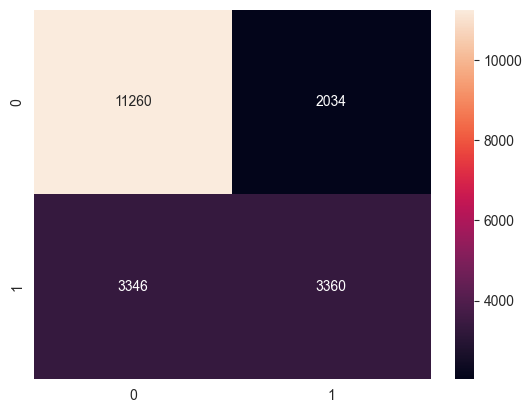

In [41]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot = True, fmt = "d")
plt.show()

Feature Importance

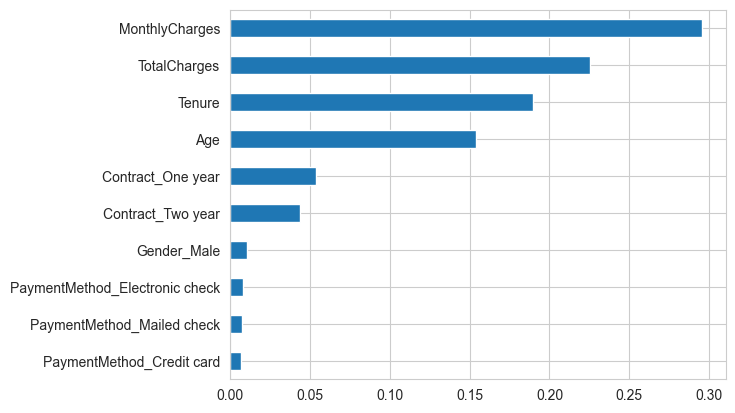

In [44]:
importance = pd.Series(model.feature_importances_, index = X.columns)
importance.sort_values().tail(10).plot(kind = "barh")
plt.show()
